# M5.7 Lab — Comparación de AE, DAE y VAE con Cats vs Dogs

## Objetivo
Implementar y comparar **Autoencoder (AE)**, **Denoising Autoencoder (DAE)** y **Variational Autoencoder (VAE)** usando las mismas imágenes RGB de Cats vs Dogs, el mismo tamaño de entrada, dimensión latente, batch size, optimizador y número de épocas.

Este notebook está construido a partir de la estructura y técnicas de los notebooks de referencia compartidos en el módulo:
- `M5_2_Autoencoder_I.ipynb` y `M5_2_Autoencoder_II.ipynb`: bloques convolucionales y reconstrucción con autoencoders.
- `M5_3_DAE.ipynb`: ruido Gaussiano nuevo en cada batch y objetivo noisy → clean.
- `M5_4_VAE.ipynb`: `mu`, `logvar`, reparameterization trick, pérdida KL y muestreo desde `N(0,I)`.

> **Nota sobre el enunciado:** algunas preguntas originales mencionan “dígitos” y “MNIST”, pero el dataset solicitado es **DogsVsCats**. En este notebook esas referencias se interpretan como **gatos y perros**.

Primeramente, se obtiene el flujo a seguir para lograr el objetivo de este laboratorio:


<div align="center">

## Flujo general del laboratorio M5.7 – Autoencoders

El laboratorio utiliza el dataset **Cats vs Dogs** almacenado en `catsvsdogs.zip`.  
El flujo de trabajo seguido para cargar los datos, entrenar los modelos y realizar las comparaciones es el siguiente:

<br>

**Imports y configuración**

↓  

**Carga de `catsvsdogs.zip`**  
mediante `files.upload()`

↓  

**Descompresión del dataset**

↓

<pre>
./data/catsvsdogs/
├── 0/  → Cat
└── 1/  → Dog
</pre>

↓

**Creación de**  
`image_paths` + `labels_np`

↓

**CatsDogsDataset**

↓

**División del dataset**  
Train / Validation / Test

↓

### Autoencoder (AE)

↓

### Denoising Autoencoder (DAE)

↓

### Variational Autoencoder (VAE)

↓

**Comparación de los espacios latentes**  
mediante UMAP

↓

**Interpolación en el espacio latente**

↓

**Generación de nuevas imágenes**  
desde el VAE

↓

### AE vs DAE vs VAE

↓

**Métricas, análisis, preguntas y conclusiones**

</div>

In [1]:
# Instalación de dependencias (Colab/Jupyter)
!pip -q install torchinfo umap-learn

import os, random, zipfile, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchinfo import summary

from sklearn.model_selection import train_test_split
import umap.umap_ as umap

warnings.filterwarnings('ignore')

SEED = 42
IMAGE_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 10
LATENT_DIM = 64
LR = 1e-3
NOISE_STD = 0.30
BETA = 1.0
NUM_WORKERS = 2
UMAP_SAMPLES = 1500

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = get_device()
print('Using device:', device)

Using device: cpu


## 0. Cargar `catsvsdogs.zip`

Este código nos ayuda a subir manualmente la carpeta .zip Después lo descomprime y detecta automáticamente las imágenes de **Cat** y **Dog** tanto por nombre de carpeta como por nombre de archivo.

In [2]:
# ============================================================
# CARGAR Y DESCOMPRIMIR CATSVSDOGS.ZIP
# Basado en M5_5_MAE
# ============================================================

from google.colab import files
from pathlib import Path
import zipfile
import shutil

# Seleccionar manualmente catsvsdogs.zip desde la computadora
uploaded = files.upload()

zip_name = "catsvsdogs.zip"
assert zip_name in uploaded, f"Se esperaba el archivo {zip_name}"

# Carpeta donde quedará almacenado el dataset
DATA_DIR = Path("./data/catsvsdogs")
DATA_DIR.parent.mkdir(parents=True, exist_ok=True)

# Descomprimir el archivo ZIP
with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR.parent)

# Ajustar la carpeta extraída para que ImageFolder encuentre
# exactamente:
#
# ./data/catsvsdogs/0
# ./data/catsvsdogs/1
#
# donde:
# 0 = cat
# 1 = dog

if not (DATA_DIR / "0").exists() or not (DATA_DIR / "1").exists():

    candidates = [
        p for p in DATA_DIR.parent.iterdir()
        if p.is_dir()
    ]

    source_dir = next(
        (
            p for p in candidates
            if (p / "0").exists() and (p / "1").exists()
        ),
        None
    )

    assert source_dir is not None, (
        "El ZIP debe contener las carpetas 0 y 1 (cat y dog)."
    )

    if source_dir != DATA_DIR:

        if DATA_DIR.exists():
            shutil.rmtree(DATA_DIR)

        source_dir.rename(DATA_DIR)

# Verificación del dataset
print(f"Dataset listo en: {DATA_DIR.resolve()}")
print(f"Gatos: {len(list((DATA_DIR / '0').glob('*')))}")
print(f"Perros: {len(list((DATA_DIR / '1').glob('*')))}")

Saving catsvsdogs.zip to catsvsdogs.zip
Dataset listo en: /content/data/catsvsdogs
Gatos: 12500
Perros: 12500


In [3]:
# ============================================================
# DETECTAR IMÁGENES Y ETIQUETAS
# 0 = cat
# 1 = dog
# ============================================================

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

image_paths = []
labels = []

# Carpeta 0 = gatos
cat_dir = DATA_DIR / "0"

for p in cat_dir.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXTS:
        image_paths.append(p)
        labels.append(0)

# Carpeta 1 = perros
dog_dir = DATA_DIR / "1"

for p in dog_dir.rglob("*"):
    if p.is_file() and p.suffix.lower() in IMG_EXTS:
        image_paths.append(p)
        labels.append(1)

# Verificar que se encontraron imágenes
if not image_paths:
    raise RuntimeError(
        "No se detectaron imágenes dentro de las carpetas 0 y 1."
    )

labels_np = np.array(labels)

print("Total images found:", len(image_paths))
print("Cats:", int((labels_np == 0).sum()))
print("Dogs:", int((labels_np == 1).sum()))
print("Example path:", image_paths[0])

Total images found: 25000
Cats: 12500
Dogs: 12500
Example path: data/catsvsdogs/0/cat.9881.jpg


In [4]:
class CatsDogsDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # Algunos CatsVsDogs históricos contienen uno o dos JPG corruptos.
        # Si ocurre, avanzamos al siguiente elemento de forma determinista.
        for offset in range(10):
            j = (idx + offset) % len(self.paths)
            try:
                with Image.open(self.paths[j]) as img:
                    img = img.convert('RGB')
                    if self.transform:
                        img = self.transform(img)
                return img, int(self.labels[j])
            except Exception:
                continue
        raise RuntimeError(f'No fue posible leer una imagen válida cerca del índice {idx}.')

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                 # píxeles en [0,1]
])

indices = np.arange(len(image_paths))
train_idx, test_idx = train_test_split(
    indices, test_size=0.20, random_state=SEED, stratify=labels_np
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.125, random_state=SEED, stratify=labels_np[train_idx]
)  # 70% train, 10% val, 20% test

train_dataset = CatsDogsDataset([image_paths[i] for i in train_idx], labels_np[train_idx], transform)
val_dataset   = CatsDogsDataset([image_paths[i] for i in val_idx], labels_np[val_idx], transform)
test_dataset  = CatsDogsDataset([image_paths[i] for i in test_idx], labels_np[test_idx], transform)

g = torch.Generator().manual_seed(SEED)
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=(device.type == 'cuda'))
train_loader = DataLoader(train_dataset, shuffle=True, generator=g, **loader_kwargs)
val_loader   = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Train: 17500 | Val: 2500 | Test: 5000


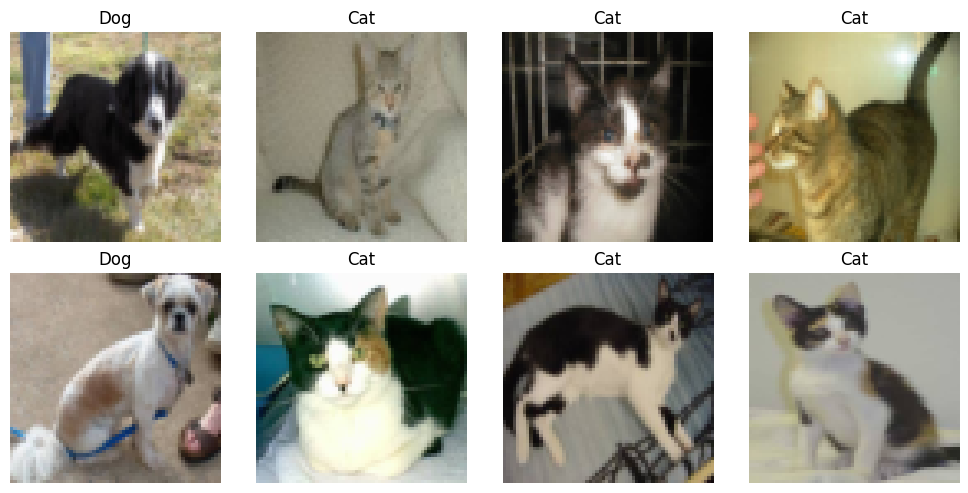

In [5]:
# Visualizar ejemplos del dataset
x_preview, y_preview = next(iter(train_loader))
class_names = ['Cat', 'Dog']
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_preview[i].permute(1, 2, 0))
    ax.set_title(class_names[y_preview[i].item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 1. Arquitectura común para AE y DAE

Siguiendo los autoencoders convolucionales de `M5_2`/`M5_3`, el encoder reduce progresivamente la resolución espacial y el decoder la recupera con `ConvTranspose2d`. Para que la comparación con el VAE sea directa, se usa un **vector latente de dimensión `LATENT_DIM`** en los tres modelos.

In [6]:
class ConvEncoder(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 16, 4, 2, 1), nn.ReLU(inplace=True),   # 64 -> 32
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(inplace=True),            # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(inplace=True),            # 16 -> 8
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(inplace=True),           # 8 -> 4
            nn.Flatten(),
        )
        self.feature_shape = (128, 4, 4)
        self.feature_dim = int(np.prod(self.feature_shape))

    def forward(self, x):
        return self.net(x)


class ConvDecoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, out_channels=3):
        super().__init__()
        self.feature_shape = (128, 4, 4)
        self.fc = nn.Linear(latent_dim, int(np.prod(self.feature_shape)))
        self.net = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(inplace=True),  # 4 -> 8
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(inplace=True),   # 8 -> 16
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(inplace=True),   # 16 -> 32
            nn.ConvTranspose2d(16, out_channels, 4, 2, 1), nn.Sigmoid(), # 32 -> 64
        )

    def forward(self, z):
        x = self.fc(z).view(z.size(0), *self.feature_shape)
        return self.net(x)


class ConvAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder_backbone = ConvEncoder(in_channels)
        self.fc_latent = nn.Linear(self.encoder_backbone.feature_dim, latent_dim)
        self.decoder = ConvDecoder(latent_dim, in_channels)

    def encode(self, x):
        return self.fc_latent(self.encoder_backbone(x))

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))

# AE y DAE tienen exactamente la misma arquitectura; solo cambia cómo se entrenan.
ae = ConvAE().to(device)
dae = ConvAE().to(device)
summary(ae, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
        col_names=('input_size', 'output_size', 'num_params'), depth=3)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvAE                                   [1, 3, 64, 64]            [1, 3, 64, 64]            --
├─ConvEncoder: 1-1                       [1, 3, 64, 64]            [1, 2048]                 --
│    └─Sequential: 2-1                   [1, 3, 64, 64]            [1, 2048]                 --
│    │    └─Conv2d: 3-1                  [1, 3, 64, 64]            [1, 16, 32, 32]           784
│    │    └─ReLU: 3-2                    [1, 16, 32, 32]           [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-3                  [1, 16, 32, 32]           [1, 32, 16, 16]           8,224
│    │    └─ReLU: 3-4                    [1, 32, 16, 16]           [1, 32, 16, 16]           --
│    │    └─Conv2d: 3-5                  [1, 32, 16, 16]           [1, 64, 8, 8]             32,832
│    │    └─ReLU: 3-6                    [1, 64, 8, 8]             [1, 64, 8, 8]             --
│    │    └─Conv2d: 3-7    

In [7]:
def evaluate_mse(model, loader, noisy_std=None):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for clean, _ in loader:
            clean = clean.to(device)
            inp = add_noise(clean, noisy_std) if noisy_std is not None else clean
            recon = model(inp)
            loss = F.mse_loss(recon, clean, reduction='mean')
            total += loss.item() * clean.size(0)
            n += clean.size(0)
    return total / n


def train_deterministic_ae(model, train_loader, val_loader, epochs=EPOCHS,
                           lr=LR, noise_std=None):
    """AE si noise_std=None; DAE si noise_std es un número."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {'train': [], 'val': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        seen = 0
        for clean, _ in train_loader:
            clean = clean.to(device)
            # Igual que M5_3_DAE: ruido NUEVO en cada batch.
            inp = add_noise(clean, noise_std) if noise_std is not None else clean

            optimizer.zero_grad()
            recon = model(inp)
            loss = criterion(recon, clean)
            loss.backward()
            optimizer.step()

            running += loss.item() * clean.size(0)
            seen += clean.size(0)

        train_loss = running / seen
        val_loss = evaluate_mse(model, val_loader, noisy_std=noise_std)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        print(f'epoch {epoch:2d}/{epochs} - train: {train_loss:.6f} - val: {val_loss:.6f}')

    return history


def add_noise(x, std=NOISE_STD):
    """Misma idea de M5_3_DAE: Gaussian noise y clamp a [0,1]."""
    return (x + std * torch.randn_like(x)).clamp(0, 1)

## 2. Autoencoder (AE)

El AE aprende directamente `x → z → x_hat` minimizando MSE. No recibe etiquetas durante el entrenamiento.

epoch  1/10 - train: 0.035270 - val: 0.022243
epoch  2/10 - train: 0.019104 - val: 0.017144
epoch  3/10 - train: 0.015941 - val: 0.015066
epoch  4/10 - train: 0.014314 - val: 0.013423
epoch  5/10 - train: 0.012795 - val: 0.012383
epoch  6/10 - train: 0.011686 - val: 0.011407
epoch  7/10 - train: 0.011118 - val: 0.010971
epoch  8/10 - train: 0.010774 - val: 0.010852
epoch  9/10 - train: 0.010575 - val: 0.010802
epoch 10/10 - train: 0.010471 - val: 0.010623
AE test MSE: 0.010621


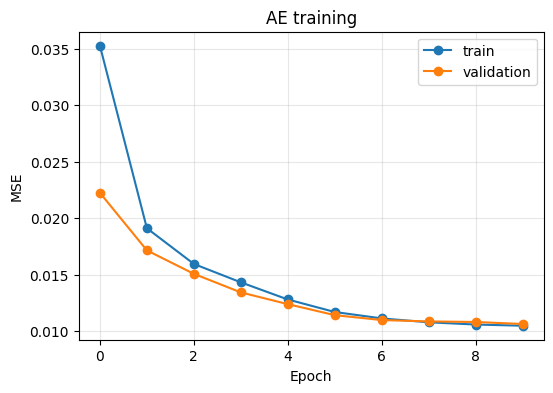

In [8]:
ae_history = train_deterministic_ae(ae, train_loader, val_loader, noise_std=None)
ae_test_mse = evaluate_mse(ae, test_loader)
print(f'AE test MSE: {ae_test_mse:.6f}')

plt.figure(figsize=(6,4))
plt.plot(ae_history['train'], marker='o', label='train')
plt.plot(ae_history['val'], marker='o', label='validation')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('AE training'); plt.legend(); plt.grid(alpha=.3)
plt.show()

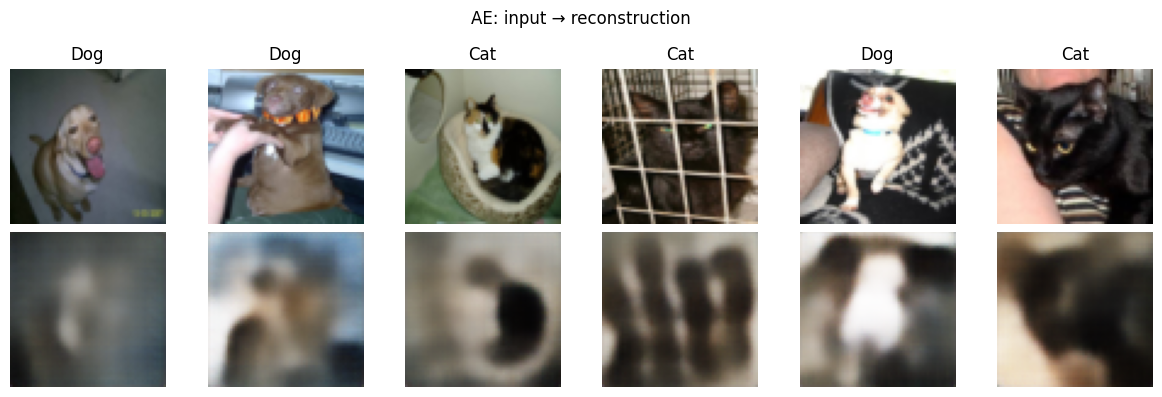

In [9]:
def show_reconstructions(model, loader, n=6, title=''):
    model.eval()
    x, y = next(iter(loader))
    with torch.no_grad():
        r = model(x[:n].to(device)).cpu()
    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0,i].imshow(x[i].permute(1,2,0)); axes[0,i].axis('off')
        axes[0,i].set_title(class_names[y[i].item()])
        axes[1,i].imshow(r[i].permute(1,2,0).clamp(0,1)); axes[1,i].axis('off')
    axes[0,0].set_ylabel('Input'); axes[1,0].set_ylabel('Recon')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_reconstructions(ae, test_loader, title='AE: input → reconstruction')

### Pregunta AE
**¿Los dígitos forman grupos en el espacio latente aunque el modelo nunca utiliza las etiquetas?**

Adaptado a este laboratorio: **¿gatos y perros forman grupos aunque el AE nunca utiliza las etiquetas?**

**Respuesta:** pueden aparecer **grupos parciales**, pero no están garantizados. El AE se optimiza para reconstruir píxeles, no para separar clases. Si rasgos visuales útiles para reconstruir (forma de cara, textura del pelaje, orejas, fondo, pose) coinciden con la diferencia gato/perro, UMAP puede mostrar cierta separación. También es normal observar solapamiento porque iluminación, fondo y pose pueden dominar parte de la representación. Las etiquetas se usan únicamente después del entrenamiento para colorear el UMAP.

## 3. Denoising Autoencoder (DAE)

Siguiendo `M5_3_DAE`, se genera ruido Gaussiano **nuevo en cada batch**. La entrada es `noisy`, pero el target continúa siendo la imagen limpia.

epoch  1/10 - train: 0.039201 - val: 0.021816
epoch  2/10 - train: 0.019068 - val: 0.017283
epoch  3/10 - train: 0.016075 - val: 0.015485
epoch  4/10 - train: 0.014910 - val: 0.014521
epoch  5/10 - train: 0.014149 - val: 0.013920
epoch  6/10 - train: 0.013541 - val: 0.013656
epoch  7/10 - train: 0.012896 - val: 0.012299
epoch  8/10 - train: 0.011873 - val: 0.011644
epoch  9/10 - train: 0.011383 - val: 0.011391
epoch 10/10 - train: 0.011207 - val: 0.011393
DAE test MSE (clean input): 0.017184
DAE test MSE (noise std=0.3): 0.011386


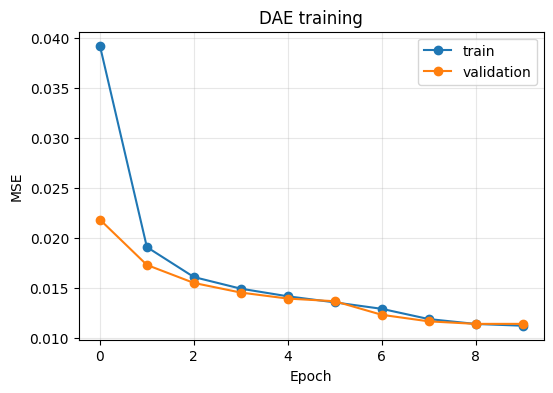

In [10]:
dae_history = train_deterministic_ae(
    dae, train_loader, val_loader, noise_std=NOISE_STD
)
dae_test_mse_clean = evaluate_mse(dae, test_loader)
dae_test_mse_noise = evaluate_mse(dae, test_loader, noisy_std=NOISE_STD)
print(f'DAE test MSE (clean input): {dae_test_mse_clean:.6f}')
print(f'DAE test MSE (noise std={NOISE_STD}): {dae_test_mse_noise:.6f}')

plt.figure(figsize=(6,4))
plt.plot(dae_history['train'], marker='o', label='train')
plt.plot(dae_history['val'], marker='o', label='validation')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('DAE training'); plt.legend(); plt.grid(alpha=.3)
plt.show()

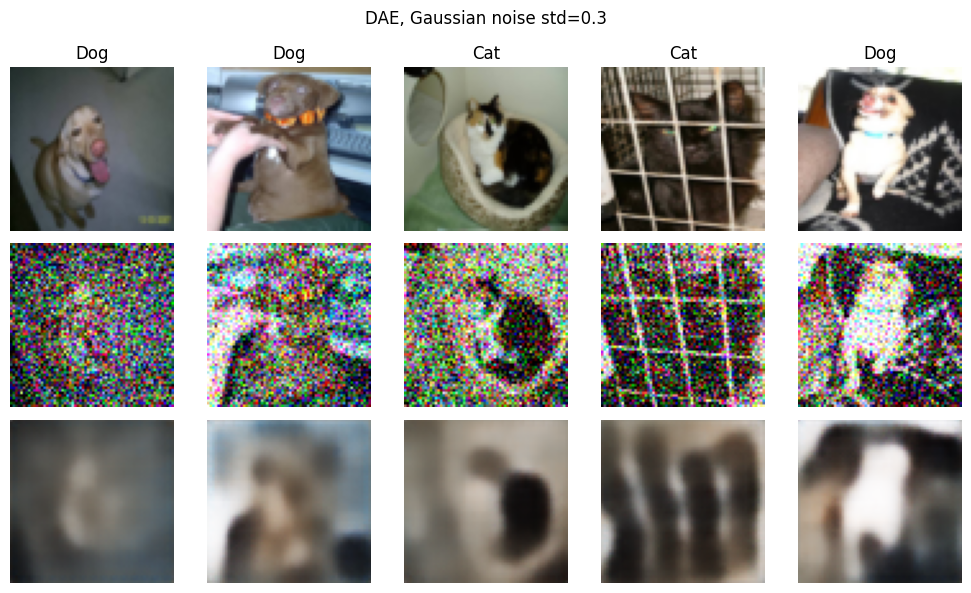

In [11]:
# clean -> noisy -> reconstruction
clean, y = next(iter(test_loader))
noisy = add_noise(clean, NOISE_STD)
dae.eval()
with torch.no_grad():
    recon = dae(noisy.to(device)).cpu()

n = 5
fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
for i in range(n):
    for row, img in enumerate([clean[i], noisy[i], recon[i]]):
        axes[row,i].imshow(img.permute(1,2,0).clamp(0,1)); axes[row,i].axis('off')
    axes[0,i].set_title(class_names[y[i].item()])
axes[0,0].set_ylabel('Clean'); axes[1,0].set_ylabel('Noisy'); axes[2,0].set_ylabel('Recon')
plt.suptitle(f'DAE, Gaussian noise std={NOISE_STD}')
plt.tight_layout(); plt.show()

,noise_std,AE_MSE,DAE_MSE
0,0.0,0.010621,0.017184
1,0.1,0.010869,0.015606
2,0.2,0.011923,0.012664
3,0.3,0.014001,0.011384
4,0.4,0.016947,0.012616
5,0.5,0.020394,0.015407


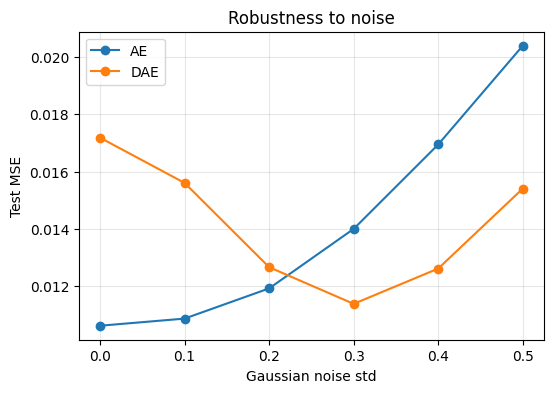

In [12]:
# Robustez del AE vs DAE frente a varios niveles de ruido
noise_levels = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
robustness_rows = []
for std in noise_levels:
    ae_mse = evaluate_mse(ae, test_loader, noisy_std=(std if std > 0 else None))
    dae_mse = evaluate_mse(dae, test_loader, noisy_std=(std if std > 0 else None))
    robustness_rows.append({'noise_std': std, 'AE_MSE': ae_mse, 'DAE_MSE': dae_mse})

robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df)

plt.figure(figsize=(6,4))
plt.plot(robustness_df.noise_std, robustness_df.AE_MSE, marker='o', label='AE')
plt.plot(robustness_df.noise_std, robustness_df.DAE_MSE, marker='o', label='DAE')
plt.xlabel('Gaussian noise std'); plt.ylabel('Test MSE')
plt.title('Robustness to noise'); plt.legend(); plt.grid(alpha=.3); plt.show()

**Interpretación del DAE:** el DAE sacrifica parte de la especialización en reconstruir exactamente la entrada limpia para aprender representaciones estables frente a perturbaciones. Por eso, al aumentar `noise_std`, se espera que su MSE crezca más lentamente que el del AE. La tabla y la curva anteriores permiten comprobarlo cuantitativamente.

## 4. Variational Autoencoder (VAE)

Siguiendo `M5_4_VAE`, el encoder produce `mu` y `logvar`. Se usa:

\[
\sigma=\exp(0.5\,	ext{logvar}),\qquad
z=\mu+\sigma\odot\epsilon,
\quad \epsilon\sim N(0,I)
\]

y

\[
D_{KL}=-rac12\sum_j(1+	ext{logvar}_j-\mu_j^2-e^{	ext{logvar}_j}).
\]

In [13]:
class ConvVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=LATENT_DIM):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder_backbone = ConvEncoder(in_channels)
        feature_dim = self.encoder_backbone.feature_dim
        self.fc_mu = nn.Linear(feature_dim, latent_dim)
        self.fc_logvar = nn.Linear(feature_dim, latent_dim)
        self.decoder = ConvDecoder(latent_dim, in_channels)

    def encode(self, x):
        features = self.encoder_backbone(x)
        return self.fc_mu(features), self.fc_logvar(features)

    def reparameterize(self, mu, logvar):
        # M5_4_VAE: standard deviation = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        return mu + std * epsilon

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def kl_divergence(mu, logvar):
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())
    return kl_per_dim.sum(dim=1).mean()


def vae_loss(reconstruction, target, mu, logvar, beta=BETA):
    # Igual que M5_4: BCE sumada por imagen y luego promedio del batch.
    rec_per_image = F.binary_cross_entropy(
        reconstruction, target, reduction='none'
    ).flatten(1).sum(dim=1)
    rec_loss = rec_per_image.mean()
    kl_loss = kl_divergence(mu, logvar)
    total_loss = rec_loss + beta * kl_loss
    return total_loss, rec_loss, kl_loss

vae = ConvVAE().to(device)
summary(vae, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE),
        col_names=('input_size', 'output_size', 'num_params'), depth=3)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ConvVAE                                  [1, 3, 64, 64]            [1, 3, 64, 64]            --
├─ConvEncoder: 1-1                       [1, 3, 64, 64]            [1, 2048]                 --
│    └─Sequential: 2-1                   [1, 3, 64, 64]            [1, 2048]                 --
│    │    └─Conv2d: 3-1                  [1, 3, 64, 64]            [1, 16, 32, 32]           784
│    │    └─ReLU: 3-2                    [1, 16, 32, 32]           [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-3                  [1, 16, 32, 32]           [1, 32, 16, 16]           8,224
│    │    └─ReLU: 3-4                    [1, 32, 16, 16]           [1, 32, 16, 16]           --
│    │    └─Conv2d: 3-5                  [1, 32, 16, 16]           [1, 64, 8, 8]             32,832
│    │    └─ReLU: 3-6                    [1, 64, 8, 8]             [1, 64, 8, 8]             --
│    │    └─Conv2d: 3-7    

In [14]:
def evaluate_vae(model, loader):
    model.eval()
    running = {'total': 0.0, 'reconstruction': 0.0, 'kl': 0.0, 'mse': 0.0}
    n = 0
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon, mu, logvar = model(x)
            total, rec, kl = vae_loss(recon, x, mu, logvar)
            b = x.size(0)
            running['total'] += total.item() * b
            running['reconstruction'] += rec.item() * b
            running['kl'] += kl.item() * b
            running['mse'] += F.mse_loss(recon, x).item() * b
            n += b
    return {k: v/n for k,v in running.items()}


def train_vae(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {k: [] for k in ['total','reconstruction','kl','val_total','val_reconstruction','val_kl']}

    for epoch in range(1, epochs+1):
        model.train()
        running = {'total':0.0, 'reconstruction':0.0, 'kl':0.0}
        seen = 0
        for x, _ in train_loader:
            x = x.to(device)
            optimizer.zero_grad()
            recon, mu, logvar = model(x)
            total, rec, kl = vae_loss(recon, x, mu, logvar)
            total.backward()
            optimizer.step()
            b = x.size(0); seen += b
            running['total'] += total.item()*b
            running['reconstruction'] += rec.item()*b
            running['kl'] += kl.item()*b

        for k in ['total','reconstruction','kl']:
            history[k].append(running[k]/seen)

        val = evaluate_vae(model, val_loader)
        history['val_total'].append(val['total'])
        history['val_reconstruction'].append(val['reconstruction'])
        history['val_kl'].append(val['kl'])

        print(f"epoch {epoch:2d}/{epochs} - total: {history['total'][-1]:.2f} - "
              f"rec: {history['reconstruction'][-1]:.2f} - KL: {history['kl'][-1]:.2f} - "
              f"val total: {val['total']:.2f}")
    return history

vae_history = train_vae(vae, train_loader, val_loader)
vae_test = evaluate_vae(vae, test_loader)
print('VAE test:', vae_test)

epoch  1/10 - total: 7801.84 - rec: 7759.80 - KL: 42.05 - val total: 7474.46
epoch  2/10 - total: 7406.60 - rec: 7343.33 - KL: 63.27 - val total: 7354.15
epoch  3/10 - total: 7325.52 - rec: 7257.67 - KL: 67.85 - val total: 7303.43
epoch  4/10 - total: 7282.22 - rec: 7210.86 - KL: 71.36 - val total: 7269.92
epoch  5/10 - total: 7259.27 - rec: 7185.65 - KL: 73.62 - val total: 7251.03
epoch  6/10 - total: 7235.83 - rec: 7159.37 - KL: 76.46 - val total: 7215.66
epoch  7/10 - total: 7209.01 - rec: 7129.05 - KL: 79.96 - val total: 7201.30
epoch  8/10 - total: 7193.35 - rec: 7110.58 - KL: 82.77 - val total: 7186.13
epoch  9/10 - total: 7186.06 - rec: 7101.35 - KL: 84.71 - val total: 7185.46
epoch 10/10 - total: 7177.23 - rec: 7090.75 - KL: 86.48 - val total: 7176.82
VAE test: {'total': 7188.69702421875, 'reconstruction': 7102.8000234375, 'kl': 85.8970079711914, 'mse': 0.012717223340272903}


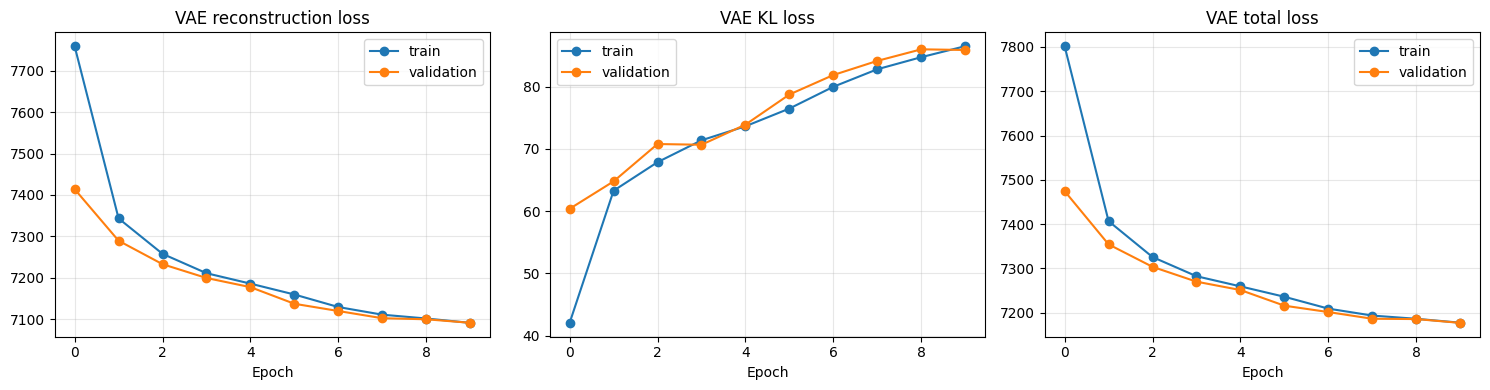

In [15]:
# Curvas separadas requeridas: reconstruction, KL y total
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, key, vkey, title in zip(
    axes,
    ['reconstruction','kl','total'],
    ['val_reconstruction','val_kl','val_total'],
    ['VAE reconstruction loss','VAE KL loss','VAE total loss']
):
    ax.plot(vae_history[key], marker='o', label='train')
    ax.plot(vae_history[vkey], marker='o', label='validation')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

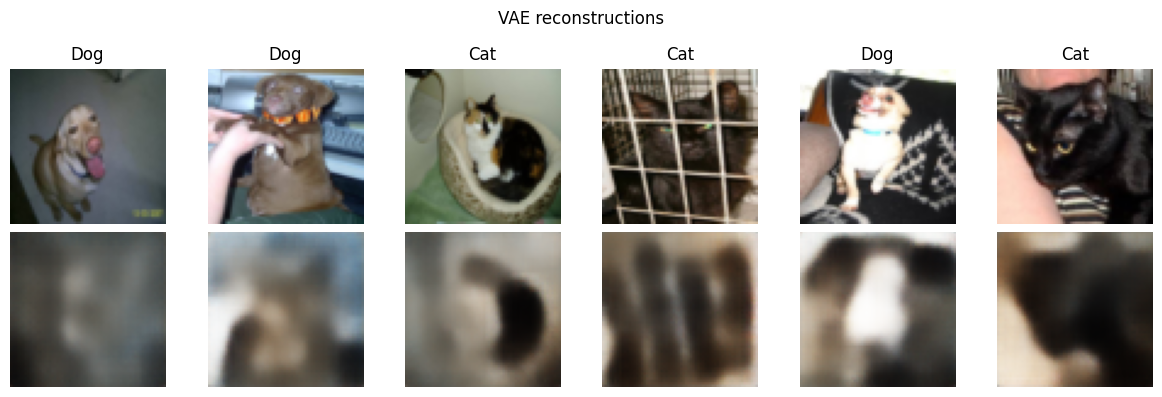

In [16]:
# Reconstrucciones VAE
x, y = next(iter(test_loader))
vae.eval()
with torch.no_grad():
    recon, mu, logvar = vae(x[:6].to(device))
recon = recon.cpu()
fig, axes = plt.subplots(2, 6, figsize=(12,4))
for i in range(6):
    axes[0,i].imshow(x[i].permute(1,2,0)); axes[0,i].axis('off'); axes[0,i].set_title(class_names[y[i].item()])
    axes[1,i].imshow(recon[i].permute(1,2,0).clamp(0,1)); axes[1,i].axis('off')
axes[0,0].set_ylabel('Input'); axes[1,0].set_ylabel('Recon')
plt.suptitle('VAE reconstructions'); plt.tight_layout(); plt.show()

### Generación de nuevas imágenes con el VAE

El término KL acerca las distribuciones posteriores a `N(0,I)`. Por ello podemos muestrear directamente del prior y usar el decoder sin imagen de entrada.

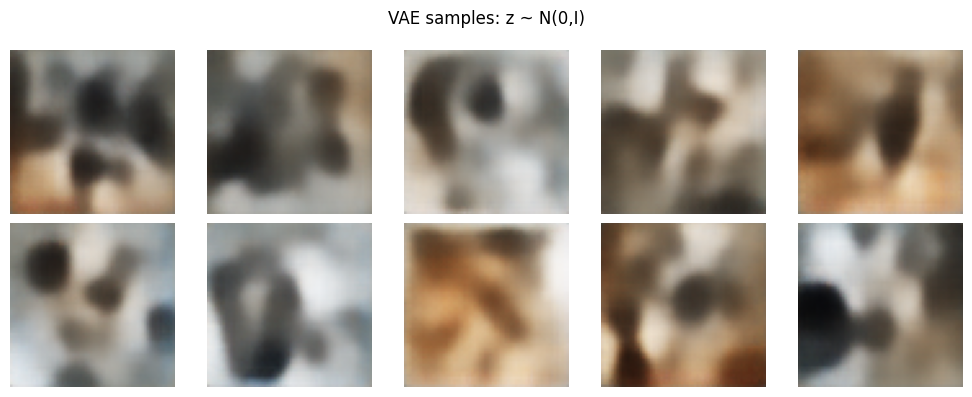

In [17]:
torch.manual_seed(7)
z_prior = torch.randn(10, LATENT_DIM, device=device)
vae.eval()
with torch.no_grad():
    generated = vae.decode(z_prior).cpu()

fig, axes = plt.subplots(2,5,figsize=(10,4))
for img, ax in zip(generated, axes.flat):
    ax.imshow(img.permute(1,2,0).clamp(0,1)); ax.axis('off')
plt.suptitle('VAE samples: z ~ N(0,I)'); plt.tight_layout(); plt.show()

## 5. Comparación de espacios latentes con UMAP

Se usan exactamente las mismas imágenes de prueba. Las etiquetas **no entran en ninguno de los modelos**; solo se usan para colorear los puntos. En el VAE se usa `mu(x)` como representación determinista, tal como exige el enunciado y como se hace en `M5_4_VAE`.

In [18]:
# Subconjunto fijo para UMAP
umap_n = min(UMAP_SAMPLES, len(test_dataset))
umap_subset = Subset(test_dataset, list(range(umap_n)))
umap_loader = DataLoader(umap_subset, batch_size=256, shuffle=False, num_workers=NUM_WORKERS)

def collect_latents_deterministic(model, loader):
    model.eval(); zs=[]; ys=[]
    with torch.no_grad():
        for x,y in loader:
            zs.append(model.encode(x.to(device)).cpu())
            ys.append(y)
    return torch.cat(zs).numpy(), torch.cat(ys).numpy()

def collect_latents_vae(model, loader):
    model.eval(); zs=[]; ys=[]
    with torch.no_grad():
        for x,y in loader:
            mu,_ = model.encode(x.to(device))
            zs.append(mu.cpu()); ys.append(y)
    return torch.cat(zs).numpy(), torch.cat(ys).numpy()

z_ae, y_umap = collect_latents_deterministic(ae, umap_loader)
z_dae, _ = collect_latents_deterministic(dae, umap_loader)
z_vae, _ = collect_latents_vae(vae, umap_loader)

embeddings = {}
for name, z in [('AE', z_ae), ('DAE', z_dae), ('VAE', z_vae)]:
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=20, min_dist=0.15)
    embeddings[name] = reducer.fit_transform(z)

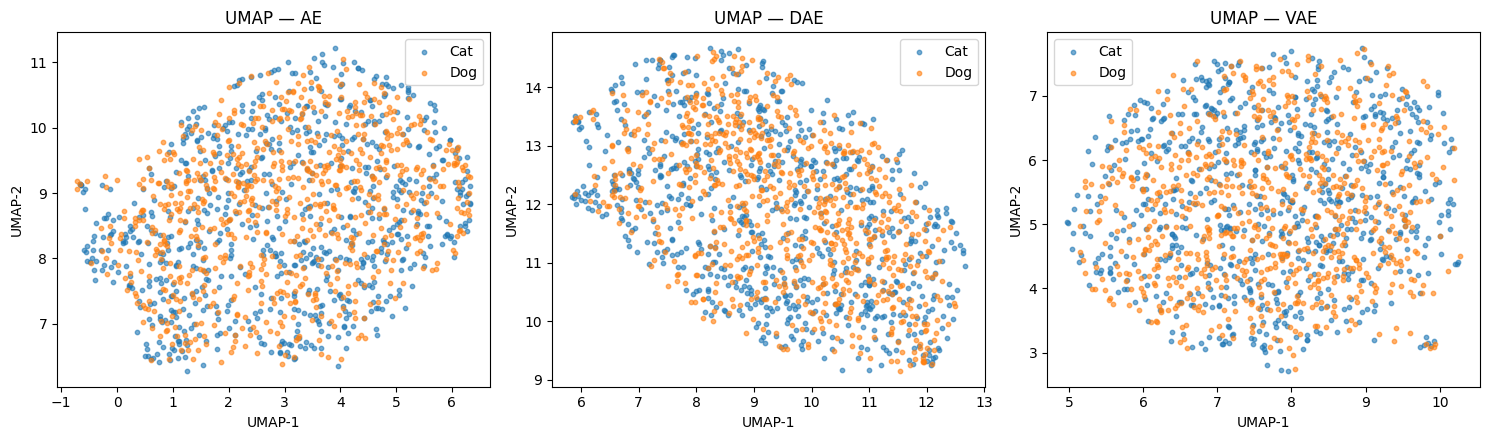

In [19]:
fig, axes = plt.subplots(1,3,figsize=(15,4.5))
for ax, name in zip(axes, ['AE','DAE','VAE']):
    emb = embeddings[name]
    for cls, label_name in enumerate(class_names):
        m = y_umap == cls
        ax.scatter(emb[m,0], emb[m,1], s=10, alpha=.6, label=label_name)
    ax.set_title(f'UMAP — {name}'); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
    ax.legend()
plt.tight_layout(); plt.show()

### Análisis del espacio latente

- **Separación entre clases:** AE/DAE pueden separar parcialmente gatos y perros si los rasgos necesarios para reconstrucción coinciden con rasgos de clase; no hay una pérdida supervisada que obligue a separarlos.
- **Solapamiento:** es esperable en los tres modelos por variaciones de fondo, pose, escala, iluminación y apariencia.
- **Continuidad:** el VAE debería mostrar una organización más continua porque KL regulariza cada posterior hacia un prior común.
- **Regiones vacías:** AE y DAE pueden dejar huecos arbitrarios entre códigos observados. El VAE penaliza distribuciones alejadas del prior y normalmente reduce esos huecos, aunque un `BETA` demasiado pequeño puede hacer la regularización débil.
- **DAE:** suele producir representaciones más estables frente a pequeñas perturbaciones porque fue entrenado a ignorar ruido y reconstruir la señal limpia.

La figura anterior es la evidencia empírica que debe usarse para matizar estas conclusiones en una ejecución concreta.

## 6. Interpolación latente: AE vs VAE

Para evitar escoger dos ejemplos de la misma clase por accidente, se selecciona un gato y un perro del mismo batch. En VAE se interpola entre las medias `mu`, no entre muestras aleatorias.

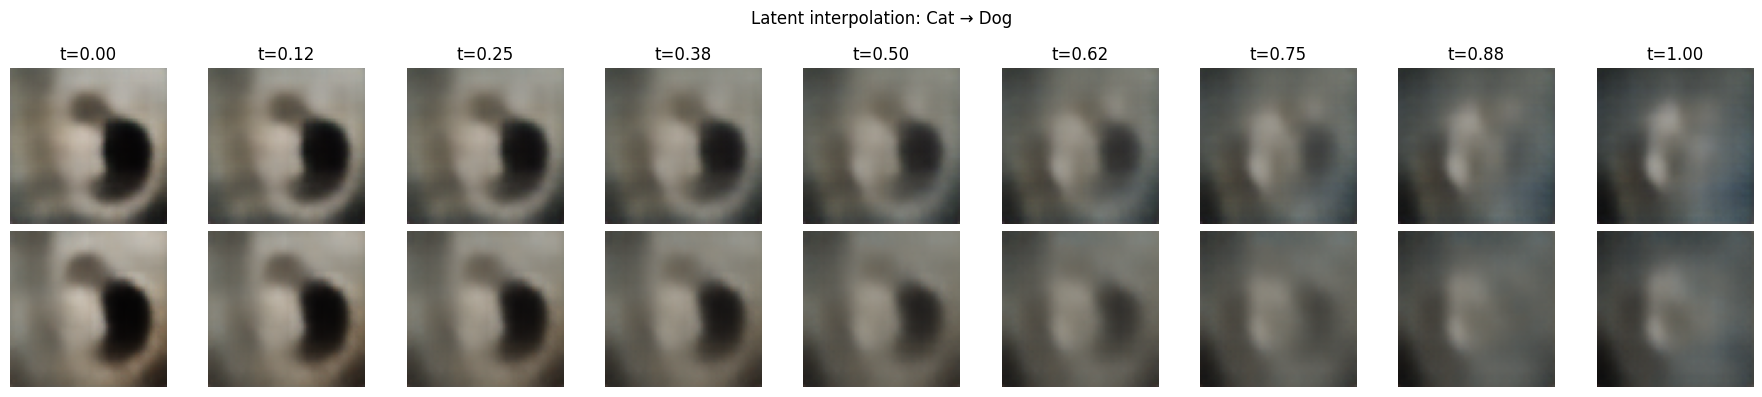

In [20]:
def find_two_classes(loader):
    for x,y in loader:
        cats = (y==0).nonzero(as_tuple=True)[0]
        dogs = (y==1).nonzero(as_tuple=True)[0]
        if len(cats) and len(dogs):
            return x[cats[0]:cats[0]+1], x[dogs[0]:dogs[0]+1]
    raise RuntimeError('No se encontraron ambas clases.')

xA, xB = find_two_classes(test_loader)
xA, xB = xA.to(device), xB.to(device)
ts = torch.linspace(0,1,9,device=device)

with torch.no_grad():
    zA_ae, zB_ae = ae.encode(xA), ae.encode(xB)
    muA,_ = vae.encode(xA); muB,_ = vae.encode(xB)

    z_interp_ae = torch.cat([(1-t)*zA_ae + t*zB_ae for t in ts], dim=0)
    z_interp_vae = torch.cat([(1-t)*muA + t*muB for t in ts], dim=0)
    imgs_ae = ae.decode(z_interp_ae).cpu()
    imgs_vae = vae.decode(z_interp_vae).cpu()

fig, axes = plt.subplots(2,len(ts),figsize=(18,4))
for i,t in enumerate(ts.cpu().numpy()):
    axes[0,i].imshow(imgs_ae[i].permute(1,2,0).clamp(0,1)); axes[0,i].axis('off'); axes[0,i].set_title(f't={t:.2f}')
    axes[1,i].imshow(imgs_vae[i].permute(1,2,0).clamp(0,1)); axes[1,i].axis('off')
axes[0,0].set_ylabel('AE'); axes[1,0].set_ylabel('VAE')
plt.suptitle('Latent interpolation: Cat → Dog'); plt.tight_layout(); plt.show()

**Interpretación de la interpolación:** el AE puede producir transiciones razonables entre dos códigos observados, pero el segmento entre ellos no está explícitamente regularizado y puede atravesar regiones del latente que el decoder casi nunca vio. En el VAE, KL favorece una región latente más continua y cercana al prior, por lo que las interpolaciones suelen ser más suaves y semánticamente coherentes, aunque las imágenes individuales pueden verse más borrosas.

## 7. Comparación final cuantitativa

Para que la comparación de reconstrucción sea justa, la métrica común es **MSE por píxel** para los tres modelos. En VAE se sigue reportando además BCE/KL/total porque forman su objetivo de entrenamiento.

In [21]:
# MSE común en test limpio
final_ae_mse = evaluate_mse(ae, test_loader)
final_dae_mse = evaluate_mse(dae, test_loader)
final_vae_mse = vae_test['mse']

# Robustez común a NOISE_STD
noise_ae = evaluate_mse(ae, test_loader, noisy_std=NOISE_STD)
noise_dae = evaluate_mse(dae, test_loader, noisy_std=NOISE_STD)

# Para VAE: evaluación MSE con entrada ruidosa contra target limpio
@torch.no_grad()
def vae_denoising_mse(model, loader, std):
    model.eval(); total=0.; n=0
    for clean,_ in loader:
        clean=clean.to(device); noisy=add_noise(clean,std)
        recon,_,_=model(noisy)
        total += F.mse_loss(recon,clean).item()*clean.size(0); n += clean.size(0)
    return total/n
noise_vae = vae_denoising_mse(vae, test_loader, NOISE_STD)

results_numeric = pd.DataFrame({
    'Model':['AE','DAE','VAE'],
    'Clean test MSE':[final_ae_mse, final_dae_mse, final_vae_mse],
    f'Noisy test MSE (std={NOISE_STD})':[noise_ae, noise_dae, noise_vae]
})
display(results_numeric)
print('VAE test reconstruction BCE:', vae_test['reconstruction'])
print('VAE test KL:', vae_test['kl'])
print('VAE test total:', vae_test['total'])

,Model,Clean test MSE,Noisy test MSE (std=0.3)
0,AE,0.010621,0.013998
1,DAE,0.017184,0.011382
2,VAE,0.012717,0.016350


VAE test reconstruction BCE: 7102.8000234375
VAE test KL: 85.8970079711914
VAE test total: 7188.69702421875


In [22]:
# Tabla solicitada. Los dos primeros renglones incorporan resultados medidos.
best_recon = results_numeric.loc[results_numeric['Clean test MSE'].idxmin(), 'Model']
best_noise = results_numeric.loc[results_numeric[f'Noisy test MSE (std={NOISE_STD})'].idxmin(), 'Model']

comparison = pd.DataFrame({
    'Propiedad':[
        'Error de reconstrucción','Robustez a ruido','Organización del latente',
        'Interpolación','Generación de nuevas muestras'
    ],
    'AE':[
        f'MSE={final_ae_mse:.6f}' + (' (mejor)' if best_recon=='AE' else ''),
        f'MSE ruido={noise_ae:.6f}' + (' (mejor)' if best_noise=='AE' else ''),
        'No regularizado; puede tener grupos y huecos',
        'Posible, pero puede cruzar regiones vacías',
        'No garantizada desde N(0,I)'
    ],
    'DAE':[
        f'MSE={final_dae_mse:.6f}' + (' (mejor)' if best_recon=='DAE' else ''),
        f'MSE ruido={noise_dae:.6f}' + (' (mejor)' if best_noise=='DAE' else ''),
        'Más estable ante perturbaciones; no regularizado globalmente',
        'Posible; no es su objetivo principal',
        'No garantizada desde N(0,I)'
    ],
    'VAE':[
        f'MSE={final_vae_mse:.6f}' + (' (mejor)' if best_recon=='VAE' else ''),
        f'MSE ruido={noise_vae:.6f}' + (' (mejor)' if best_noise=='VAE' else ''),
        'Regularizado hacia N(0,I); más continuo y sampleable',
        'Generalmente más suave por la regularización KL',
        'Sí: z ~ N(0,I) y decoder'
    ]
})
display(comparison)
print('Best clean reconstruction by MSE:', best_recon)
print(f'Best robustness at noise std={NOISE_STD}:', best_noise)

,Propiedad,AE,DAE,VAE
0,Error de reconstrucción,MSE=0.010621 (mejor),MSE=0.017184,MSE=0.012717
1,Robustez a ruido,MSE ruido=0.013998,MSE ruido=0.011382 (mejor),MSE ruido=0.016350
2,Organización del latente,No regularizado; puede tener grupos y huecos,Más estable ante perturbaciones; no regulariza...,"Regularizado hacia N(0,I); más continuo y samp..."
3,Interpolación,"Posible, pero puede cruzar regiones vacías",Posible; no es su objetivo principal,Generalmente más suave por la regularización KL
4,Generación de nuevas muestras,"No garantizada desde N(0,I)","No garantizada desde N(0,I)","Sí: z ~ N(0,I) y decoder"


Best clean reconstruction by MSE: AE
Best robustness at noise std=0.3: DAE


## 8. Preguntas finales

### 1. ¿Qué modelo obtiene mejores reconstrucciones?
La respuesta empírica es el modelo con menor **Clean test MSE** en la tabla anterior. En términos del objetivo, el **AE** suele tener ventaja en reconstrucción pura porque toda su capacidad se optimiza directamente para minimizar el error de reconstrucción. El VAE introduce la restricción KL y puede sacrificar nitidez; el DAE se entrena con entradas corruptas y prioriza robustez. En esta ejecución, usar el valor impreso como `Best clean reconstruction by MSE`.

### 2. ¿Qué modelo es más robusto al ruido?
El modelo con menor **Noisy test MSE** es el ganador medido. Conceptualmente se espera que sea el **DAE**, porque durante entrenamiento recibe ruido Gaussiano nuevo en cada batch y aprende explícitamente a mapear `noisy → clean`.

### 3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
El **AE** aprende un latente útil para reconstrucción pero sin imponer geometría global; puede formar grupos y regiones vacías. El **DAE** también es determinista, pero tiende a hacer la representación menos sensible a pequeñas perturbaciones. El **VAE** regulariza distribuciones latentes hacia `N(0,I)`, favoreciendo continuidad, solapamiento controlado y menos regiones arbitrariamente vacías. Los tres UMAP anteriores permiten observar estas diferencias usando las mismas imágenes.

### 4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
Porque el término KL minimiza la diferencia entre `q_phi(z|x)` y el prior `p(z)=N(0,I)`. Durante el entrenamiento, el decoder aprende a reconstruir a partir de muestras procedentes de distribuciones que son empujadas hacia ese prior. Por eso, después del entrenamiento, un vector aleatorio tomado de `N(0,I)` tiene una probabilidad razonable de caer en una región que el decoder sabe transformar en una imagen.

### 5. ¿Qué trade-off introduce el término KL del VAE?
KL introduce un compromiso entre **fidelidad de reconstrucción** y **regularidad del espacio latente**. Si se fuerza demasiado el prior, se pierde información específica de la entrada y las reconstrucciones pueden ser más suaves o borrosas. Si la regularización es demasiado débil, mejora la reconstrucción pero el latente pierde continuidad y la generación desde `N(0,I)` se vuelve menos confiable. `BETA` controla directamente este balance.

### 6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?
- **Reconstrucción:** AE, salvo que la tabla de MSE de esta ejecución muestre otra cosa.
- **Denoising:** DAE, porque ese es exactamente su objetivo de entrenamiento.
- **Generación:** VAE, porque su espacio latente está regularizado y permite muestrear `z ~ N(0,I)` de forma coherente.

## Conclusiones breves

1. **AE** proporciona una referencia fuerte para reconstrucción, pero su espacio latente no está obligado a ser continuo ni sampleable.
2. **DAE** cambia la tarea de entrenamiento: recibe una versión corrupta y aprende a recuperar la imagen limpia. Esto incentiva representaciones robustas a ruido.
3. **VAE** cambia el punto latente determinista por una distribución parametrizada por `mu` y `logvar`; el término KL organiza ese espacio alrededor de un prior normal.
4. La comparación justa requiere separar dos ideas: **calidad de reconstrucción** (MSE) y **calidad/estructura del latente** (UMAP, interpolación y capacidad de generación).
5. No existe un único modelo mejor para todo: AE favorece reconstrucción, DAE denoising y VAE generación/continuidad latente.

Con esto se cubren: código reproducible, curvas, reconstrucciones, ruido, UMAP, interpolación, generación VAE, tabla comparativa y preguntas del laboratorio.